In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_2ffc747c4b3d89c62d642cbda8cb153d'


path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/playground-series-s6e6


In [ ]:
df = pd.read_csv(f"{path}/train.csv")
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [ ]:
df.shape

(577347, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [ ]:
df['class'].value_counts()

,count
class,
GALAXY,377480
QSO,117143
STAR,82724


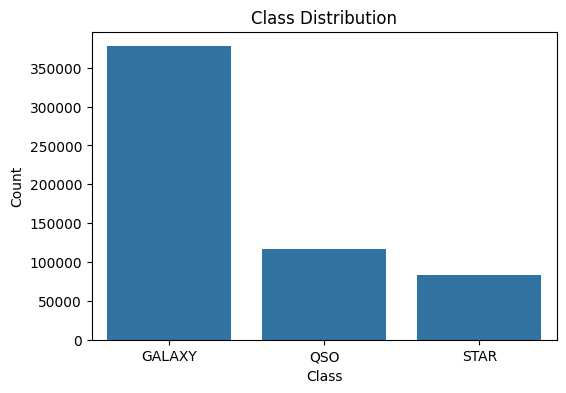

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
numerical_feature = df.select_dtypes('int64','float64')
categorical_feature = df.select_dtypes('object')


In [ ]:
df.isnull().sum()

,0
id,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
spectral_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

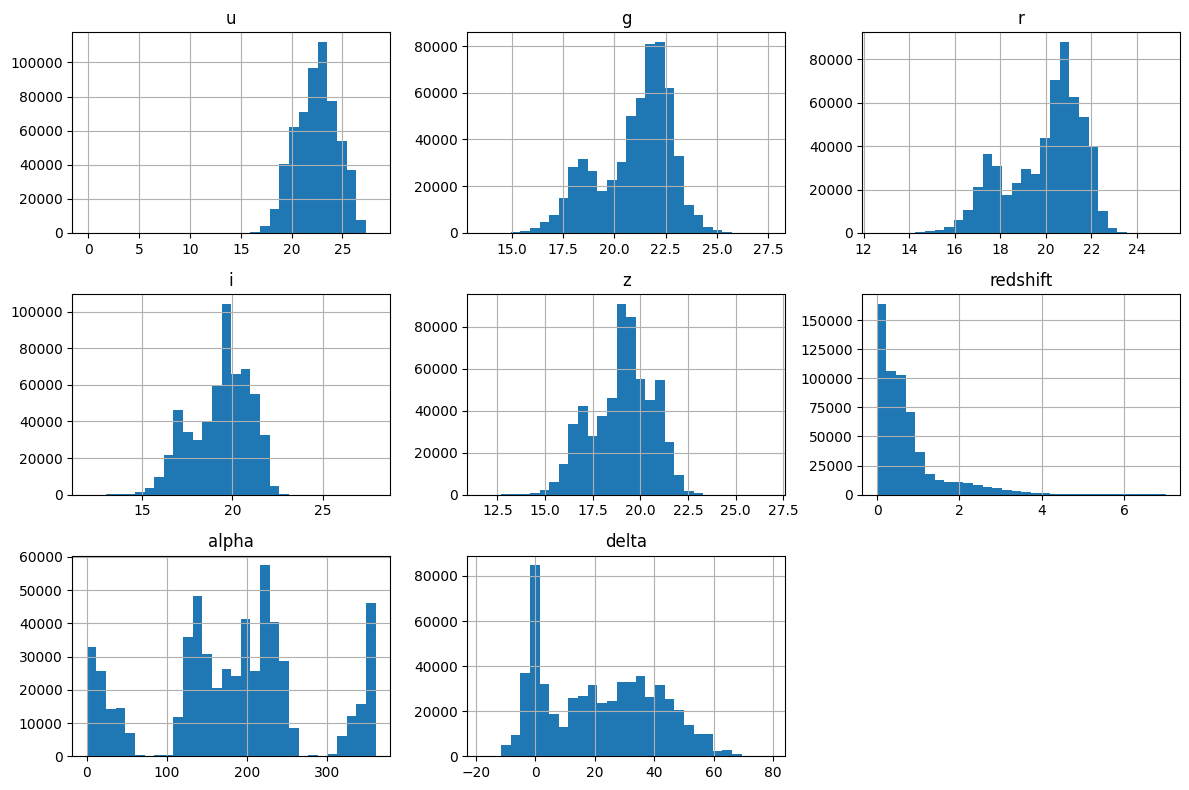

In [ ]:
num_cols = ['u', 'g', 'r', 'i', 'z', 'redshift','alpha','delta']

df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

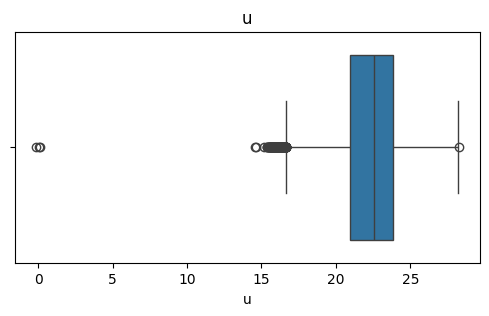

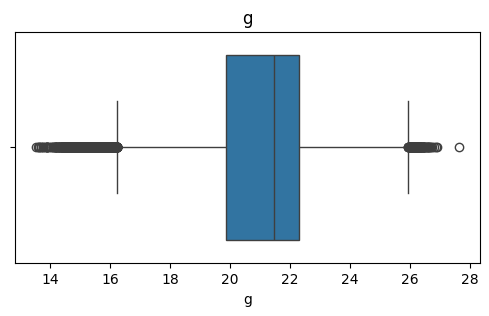

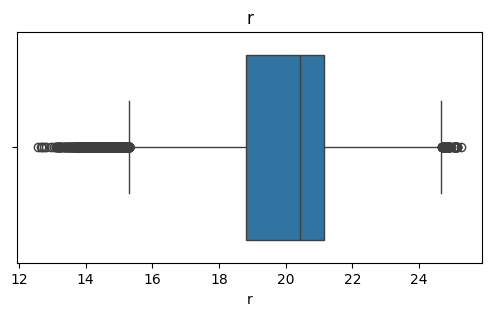

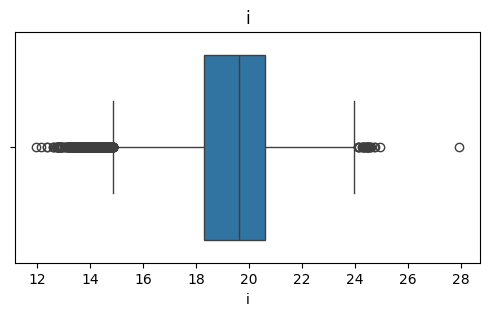

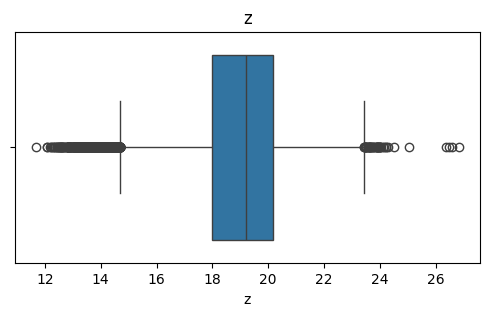

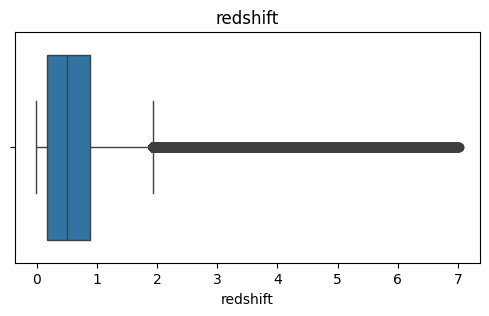

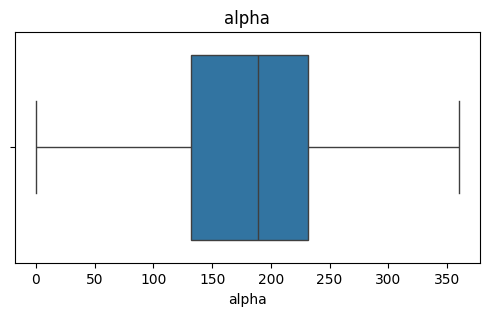

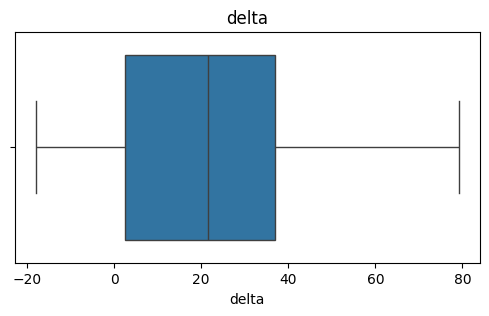

In [ ]:
# for checking outliers
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

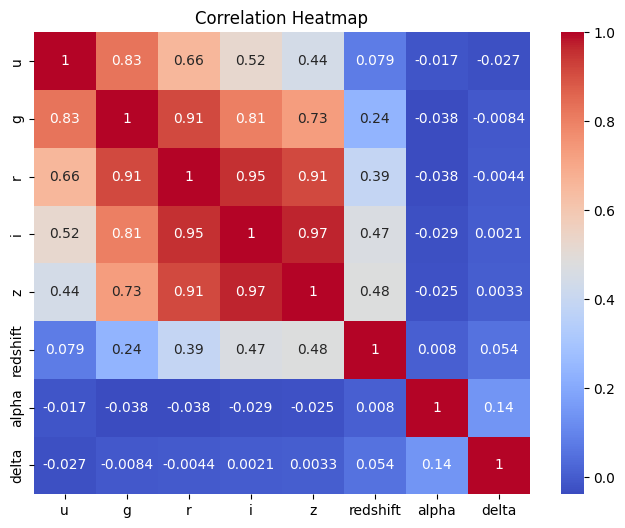

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['spectral_type' , 'galaxy_population'], drop_first = True , dtype = int)
df.head()

,id,alpha,delta,u,g,r,i,z,redshift,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,GALAXY,0,1,0,1
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,GALAXY,0,1,0,1
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,QSO,0,0,1,0
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,GALAXY,0,1,0,1
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,GALAXY,0,1,0,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

In [ ]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


In [ ]:
import joblib
joblib.dump(le, 'label_encoder.joblib')

['label_encoder.joblib']

In [ ]:
X = df.drop(columns=['class', 'class_encoded' , 'id'])
y = df['class_encoded']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 2 , stratify = y )

In [ ]:
print(X_train.shape , X_test.shape)

(461877, 12) (115470, 12)


In [ ]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 2)

In [ ]:
from sklearn.metrics import balanced_accuracy_score , accuracy_score ,f1_score , confusion_matrix , precision_score , recall_score ,classification_report
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=15,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=2)

dt_random.fit(X_train, y_train)

print("Best params:", dt_random.best_params_)
print("Best CV score:", dt_random.best_score_)
best_dt = dt_random.best_estimator_

Best params: {'min_samples_split': 100, 'min_samples_leaf': 10, 'max_depth': 12, 'criterion': 'gini'}
Best CV score: 0.9272229216288557


In [ ]:
pred_dt = dt_random.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, pred_dt, average='weighted'))
print("F1 Score:", f1_score(y_test, pred_dt, average='weighted'))

Accuracy: 0.9497358621286914
Balanced Accuracy: 0.9267363006353583
Confusion Matrix:
 [[73128   958  1410]
 [  739 22345   345]
 [ 2232   120 14193]]
Precision: 0.9493683968273365
Recall: 0.9497358621286914
F1 Score: 0.949499876180226


In [ ]:
!pip install dtreeviz

In [ ]:
import graphviz.backend as be
from IPython.display import Image,display_svg ,SVG

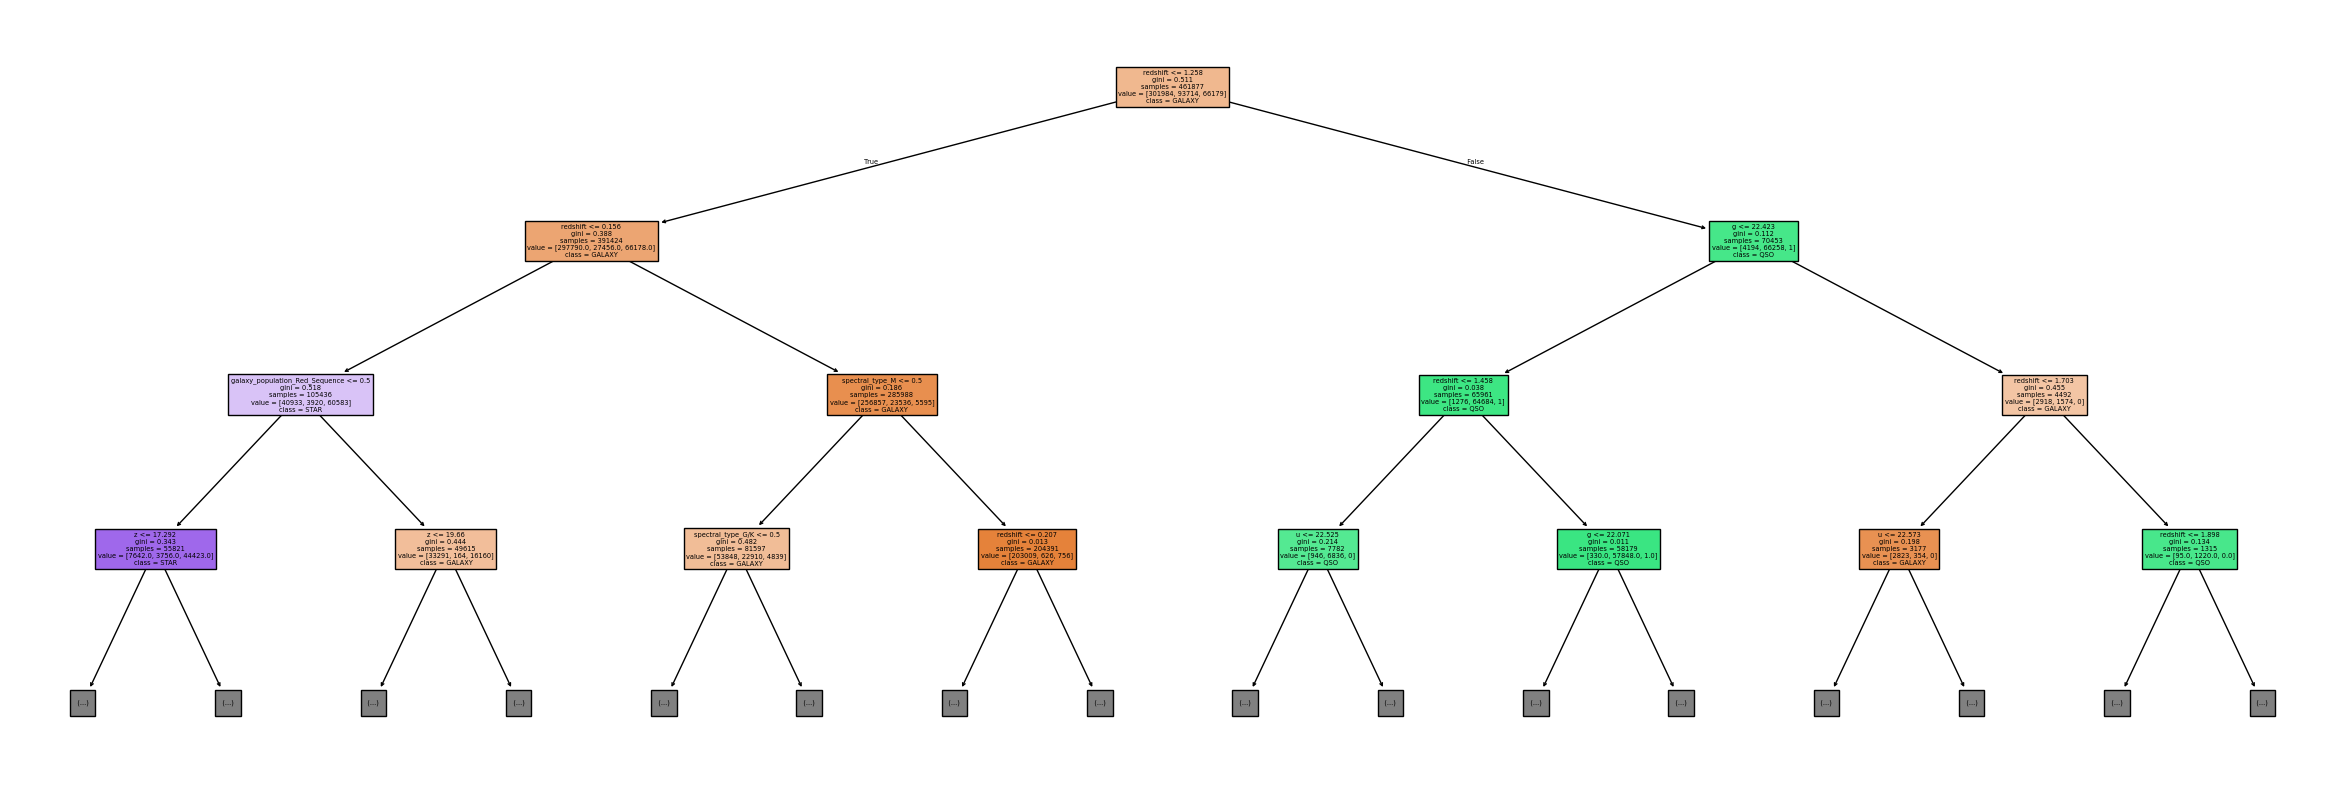

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30,10))
plot_tree(best_dt, max_depth= 3 , feature_names=X_train.columns, class_names=le.classes_, filled=True)
plt.show()

In [ ]:
import warnings
import logging

logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings('ignore')

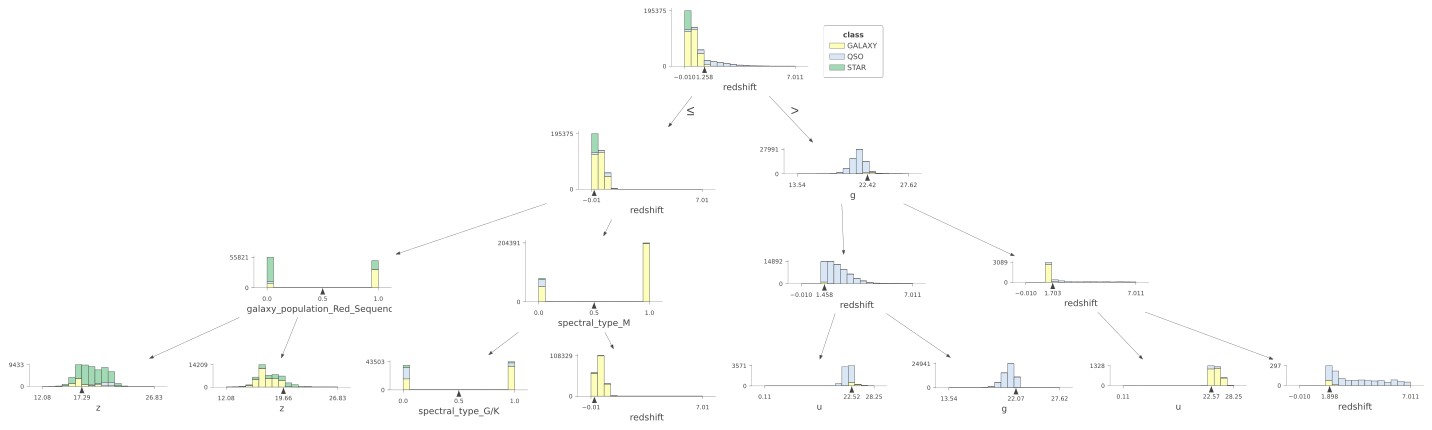

In [ ]:
from dtreeviz import model

m = model(
    best_dt,
    X_train,
    y_train,
    target_name="class",
    feature_names=list(X_train.columns),
    class_names=list(le.classes_)
)
viz = m.view(depth_range_to_display=(0, 3))
viz

In [ ]:
# create a smaller sample just for tuning (time saving)

sample_idx = X_train.sample(n=50000, random_state=42).index
X_small = X_train.loc[sample_idx]
y_small = y_train.loc[sample_idx]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_param = {
    'n_estimators': [50, 80, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param,
    n_iter=8,
    cv=skf,
    scoring='balanced_accuracy',
    n_jobs=-1,
    random_state=42
)
rf_random.fit(X_small, y_small)

print("Best parameters:", rf_random.best_params_)


best_rf = RandomForestClassifier(**rf_random.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)


pred_rf = best_rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_rf))
print("classification_report :",classification_report(y_test , pred_rf))

Best parameters: {'n_estimators': 80, 'min_samples_split': 50, 'min_samples_leaf': 10, 'max_depth': 10, 'criterion': 'entropy'}
Accuracy: 0.9489044773534251
Balanced Accuracy: 0.9256657289911768
classification_report :               precision    recall  f1-score   support

           0       0.96      0.97      0.96     75496
           1       0.96      0.95      0.96     23429
           2       0.88      0.86      0.87     16545

    accuracy                           0.95    115470
   macro avg       0.93      0.93      0.93    115470
weighted avg       0.95      0.95      0.95    115470



In [ ]:
# comapring both : Decision Tree and Random Forest
print("Decision Tree Accuracy:", balanced_accuracy_score(y_test, pred_dt))
print("Random Forest Accuracy:", balanced_accuracy_score(y_test, pred_rf))

Decision Tree Accuracy: 0.9267363006353583
Random Forest Accuracy: 0.9256657289911768


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_params = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

ada_random = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    param_distributions=ada_params,
    n_iter=8, cv=skf, scoring='balanced_accuracy', n_jobs=-1, random_state=42
)

ada_random.fit(X_small, y_small)



print("Best AdaBoost params:", ada_random.best_params_)
best_ada = ada_random.best_estimator_

best_ada = AdaBoostClassifier(**ada_random.best_params_, random_state=42)
best_ada.fit(X_train, y_train)

pred_ada = best_ada.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_ada))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_ada))
print("classification_report:",classification_report(y_test , pred_ada))

Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 0.5}
Accuracy: 0.9182038624751018
Balanced Accuracy: 0.893581527571193
classification_report:               precision    recall  f1-score   support

           0       0.95      0.94      0.94     75496
           1       0.93      0.90      0.92     23429
           2       0.79      0.84      0.81     16545

    accuracy                           0.92    115470
   macro avg       0.89      0.89      0.89    115470
weighted avg       0.92      0.92      0.92    115470



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_params = {'n_estimators': [50, 100, 150,],
             'learning_rate': [0.01, 0.05, 0.1],
             'max_depth': [3, 4, 5]}

gb_random = RandomizedSearchCV(GradientBoostingClassifier(random_state=2),
                               param_distributions=gb_params,
                               n_iter=8, cv=skf, scoring='balanced_accuracy', n_jobs=-1, random_state=2)

gb_random.fit(X_small, y_small)

print("Best Gradient Boosting params:", gb_random.best_params_)
best_gb = gb_random.best_estimator_

best_gb = GradientBoostingClassifier(**gb_random.best_params_, random_state=2)
best_gb.fit(X_train, y_train)

pred_gb = best_gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_gb))
print("Balanced Accuracy : " , balanced_accuracy_score(y_test, pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_gb))
print("classification report :" , classification_report(y_test , pred_gb))

Best Gradient Boosting params: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Accuracy: 0.9612799861435871
Balanced Accuracy :  0.9455981501213128
Confusion Matrix:
 [[73591   674  1231]
 [  674 22465   290]
 [ 1528    74 14943]]
classification report :               precision    recall  f1-score   support

           0       0.97      0.97      0.97     75496
           1       0.97      0.96      0.96     23429
           2       0.91      0.90      0.91     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470



In [ ]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=xgb_params,
    n_iter=10, cv=skf, scoring='balanced_accuracy', n_jobs=-1, random_state=42
)
xgb_random.fit(X_small, y_small)

print("Best XGBoost params:", xgb_random.best_params_)
best_xgb = xgb_random.best_estimator_

best_xgb = XGBClassifier(**xgb_random.best_params_, random_state=42, eval_metric='mlogloss')
best_xgb.fit(X_train, y_train)

pred_xgb = best_xgb.predict(X_test)
print("classification report:",classification_report(y_test,pred_xgb))
print("Accuracy:", accuracy_score(y_test, pred_xgb))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, pred_xgb))


Best XGBoost params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
classification report:               precision    recall  f1-score   support

           0       0.97      0.98      0.98     75496
           1       0.97      0.96      0.97     23429
           2       0.92      0.92      0.92     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470

Accuracy: 0.9649172945353771
Balanced Accuracy: 0.9519533177478557


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

sample_idx = X_train.sample(n=50000, random_state=42).index
X_small = X_train.loc[sample_idx]
y_small = y_train.loc[sample_idx]

estimators = [
    ('rf', best_rf),
    ('gb', best_gb),
    ('xgb', best_xgb)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=2,
    n_jobs=-1
)
stack.fit(X_small, y_small)

pred_stack = stack.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, pred_stack))
print("Stacking Balanced Accuracy:", balanced_accuracy_score(y_test, pred_stack))

Stacking Accuracy: 0.9596172165930544
Stacking Balanced Accuracy: 0.9422181674959987


In [ ]:
model_results = {
    'Decision Tree': pred_dt,
    'Random Forest': pred_rf,
    'AdaBoost': pred_ada,
    'Gradient Boosting': pred_gb,
    'XGBoost': pred_xgb,
    'Stacking Ensemble': pred_stack
}

comparison = []
for name, preds in model_results.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Balanced Accuracy': balanced_accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='weighted'),
        'Recall': recall_score(y_test, preds, average='weighted'),
        'F1 Score': f1_score(y_test, preds, average='weighted')
    })

comparison_df = pd.DataFrame(comparison).sort_values('Balanced Accuracy', ascending=False)
print(comparison_df)

               Model  Accuracy  Balanced Accuracy  Precision    Recall  \
4            XGBoost  0.964917           0.951953   0.964902  0.964917   
3  Gradient Boosting  0.961280           0.945598   0.961230  0.961280   
5  Stacking Ensemble  0.959617           0.942218   0.959429  0.959617   
0      Decision Tree  0.949736           0.926736   0.949368  0.949736   
1      Random Forest  0.948904           0.925666   0.948623  0.948904   
2           AdaBoost  0.918204           0.893582   0.919543  0.918204   

   F1 Score  
4  0.964909  
3  0.961247  
5  0.959502  
0  0.949500  
1  0.948739  
2  0.918731  


In [ ]:
import shap


X_shap = X_test.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_shap)

print(le.classes_)


['GALAXY' 'QSO' 'STAR']


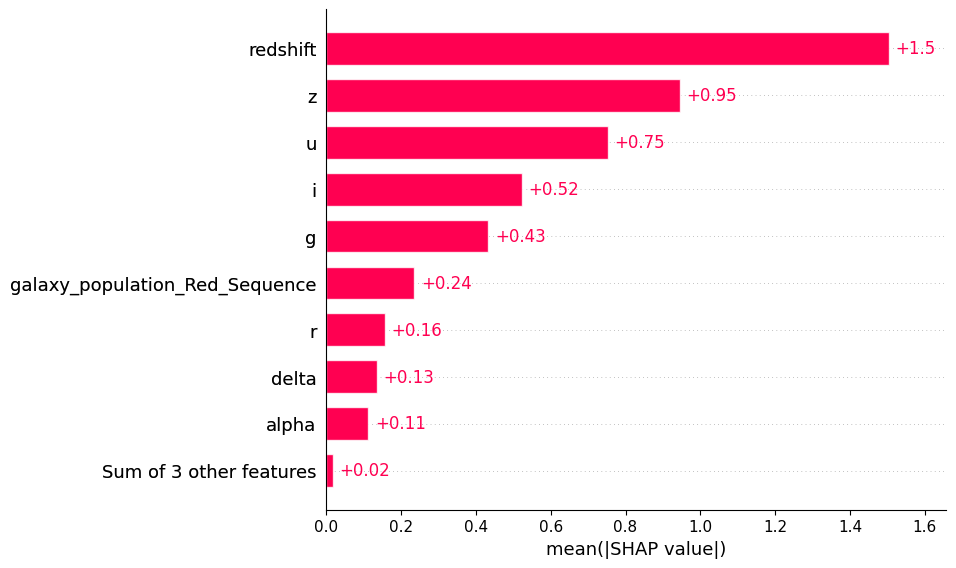

In [ ]:
shap.plots.bar(shap_values[:, :, 1])

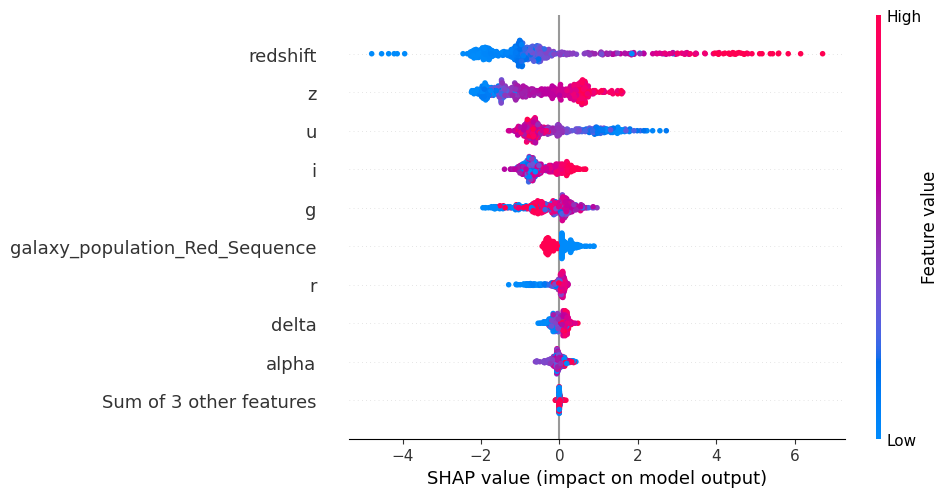

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

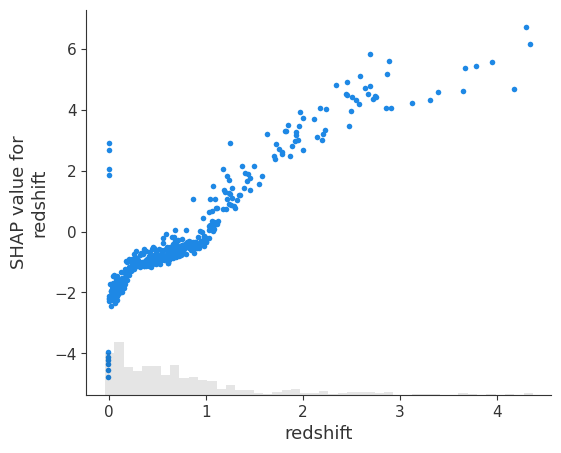

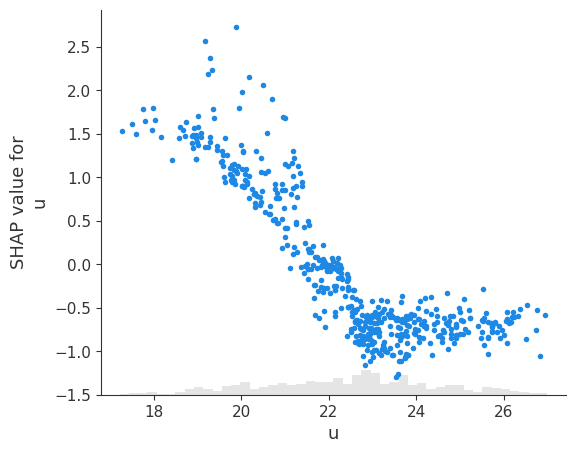

In [ ]:
shap.plots.scatter(shap_values[:, 'redshift', 1])
shap.plots.scatter(shap_values[:, 'u', 1])

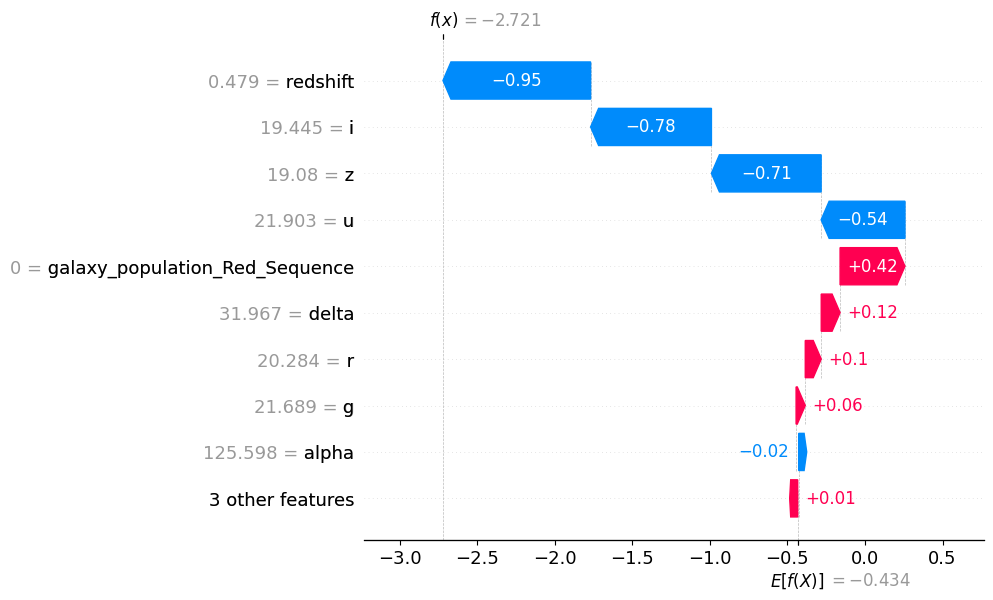

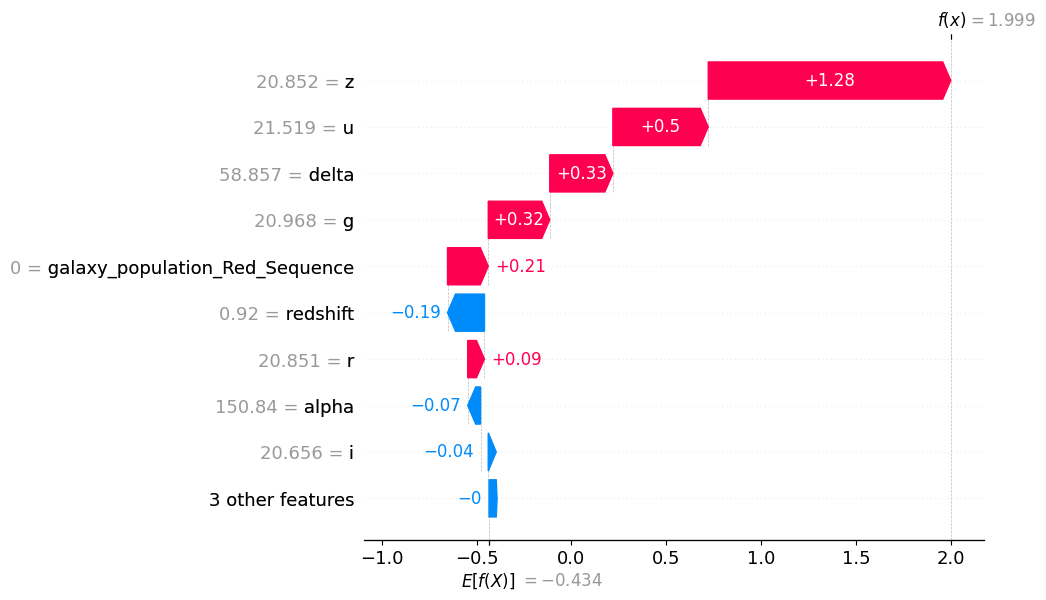

In [ ]:
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

In [ ]:
final_model = best_xgb

In [ ]:
test = pd.read_csv(f"{path}/test.csv")
test.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [ ]:
test_processed = test.drop(columns=['id'])
test_processed = pd.get_dummies(test_processed, columns=['spectral_type', 'galaxy_population'], drop_first=True, dtype=int)

test_processed = test_processed.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
final_preds = final_model.predict(test_processed)

In [ ]:
final_labels = le.inverse_transform(final_preds)

In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'class': final_labels
})
submission.to_csv('submission.csv', index=False)

In [ ]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
joblib.dump(final_model , 'best_model.pkl')
joblib.dump(le , 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
files.download('best_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X_train.columns


Index(['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B',
       'galaxy_population_Red_Sequence'],
      dtype='object')

In [ ]:
import xgboost
print(xgboost.__version__)

3.4.1


In [3]:
import os
print(os.path.getsize('best_model.pkl'))

FileNotFoundError: [Errno 2] No such file or directory: 'best_model.pkl'